# Plasmid data investigation — PlasmidScope-primary working set

**Dataset:** 208,248 complete, deduplicated, non-lab-made plasmids (PlasmidScope NAR 2025, primary;
supplemented with the IMG/PR, PLSDB, COMPASS, mMGE and INSDC source layers).

**What this notebook does.** A from-scratch investigation of every metadata layer we hold for the
working set — data-source provenance, plasmid physical properties, the *locked* environment taxonomy
(where each plasmid was sampled), replicon/Inc typing & AMR, geography, and a few cross-cutting views.

**Provenance of the data.** This notebook reads a single finalized table,
`data/plasmidscope_primary/plasmid_metadata_master.tsv`, produced by `scripts/build_metadata_master.py`,
which merges:
`scripts/build_analysis_table.py` (physical + provenance) · `scripts/reconcile_environment.py`
(locked environment taxonomy) · `scripts/enrich_plsdb_metadata.py` (PLSDB Inc/AMR/ecosystem/disease) ·
scraped IMG/M + BioSample + PLSDB geography (`scripts/scrape_img_geo.py`, `scripts/geo_utils.py`).
The notebook itself is generated by `scripts/build_investigation_notebook.py`.

**Two caveats carried throughout — the excluded non-habitat buckets.** (1) 64,658 plasmids come from
GOLD *"Modeled; Simulated communities"* samples (`hab_top = "Simulated-artifact"`); these are not a real
habitat and their coordinates collapse onto the JGI compute site. (2) 87 plasmids are lab enrichment
cultures or content-free *"Engineered"* labels with no real field site (`hab_top = "Lab-artifact"`). Both
are **excluded from every environmental and geographic analysis** below (their sequences are real, so
they are still counted in provenance and physical characterization). The clean analysis set is therefore
**143,503 plasmids**.

## 0 · Setup

Load the master table, coerce numeric columns, define the analysis set (`R`, artifact excluded), and
establish the shared plotting style + validated colorblind-safe palette used for every figure.

In [1]:
import os
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# run from the repo root regardless of where the kernel was launched (nbconvert uses the
# notebook's own directory as cwd)
while not Path("data/plasmidscope_primary/plasmid_metadata_master.tsv").exists() and Path.cwd() != Path.cwd().parent:
    os.chdir("..")

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

FIG = Path("reports/figures/investigation")
FIG.mkdir(parents=True, exist_ok=True)

# ---- validated colorblind-safe categorical palette (dataviz skill, fixed order) ----
PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK, MUTED, GRID = "#1a1a1a", "#6b7280", "#e6e8eb"
GREY, LGREY = "#9aa0a6", "#c9ccd1"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.labelcolor": INK, "text.color": INK,
    "axes.edgecolor": "#c9ccd1", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})

# domain colors (real habitats keep palette identity; non-habitat buckets are grey)
HAB_COLORS = {"Host-associated": "#2a78d6", "Environmental": "#1baf7a",
              "Engineered": "#eb6834", "Unknown": GREY, "Simulated-artifact": LGREY}


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight", facecolor="white")


def hbar_labels(ax, values, fmt="{:,.0f}", dx=None):
    # direct value labels at the end of horizontal bars
    vals = list(values)
    xmax = max(vals) if vals else 1
    dx = dx if dx is not None else xmax * 0.01
    for i, v in enumerate(vals):
        ax.text(v + dx, i, fmt.format(v), va="center", ha="left", fontsize=9, color=INK)
    ax.set_xlim(0, xmax * 1.12)

In [2]:
M = pd.read_csv("data/plasmidscope_primary/plasmid_metadata_master.tsv",
                sep="\t", dtype=str, keep_default_na=False)
for c in ["size_bp", "gc_percent", "geo_lat", "geo_lng", "n_source_dbs", "plsdb_n_inc", "plsdb_n_amr"]:
    M[c] = pd.to_numeric(M[c], errors="coerce")
M["is_clinical"] = M["is_clinical"].astype(int)

ART = M["hab_top"].isin(["Simulated-artifact", "Lab-artifact"])   # excluded non-habitat buckets
R = M[~ART].copy()                               # THE analysis set (143,503)

print(f"master: {len(M):,} plasmids x {M.shape[1]} columns")
print(f"analysis set R (artifact excluded): {len(R):,}")
print(f"columns: {list(M.columns)}")

master: 208,248 plasmids x 33 columns
analysis set R (artifact excluded): 143,503
columns: ['plasmid_id', 'sources', 'topology', 'size_bp', 'gc_percent', 'predicted_mobility', 'mob_families', 'n_source_dbs', 'env_status', 'hab_top', 'hab_sub', 'hab_channel', 'is_clinical', 'plsdb_acc', 'plsdb_inc_types', 'plsdb_n_inc', 'plsdb_rep_types', 'plsdb_relaxase', 'plsdb_mobility', 'plsdb_mob_cluster', 'plsdb_amr_genes', 'plsdb_n_amr', 'plsdb_drug_classes', 'plsdb_ecosystem_tags', 'plsdb_disease_tags', 'plsdb_species', 'geo_country', 'geo_admin1', 'geo_lat', 'geo_lng', 'geo_precision', 'geo_source', 'collection_date']


### Dataset at a glance

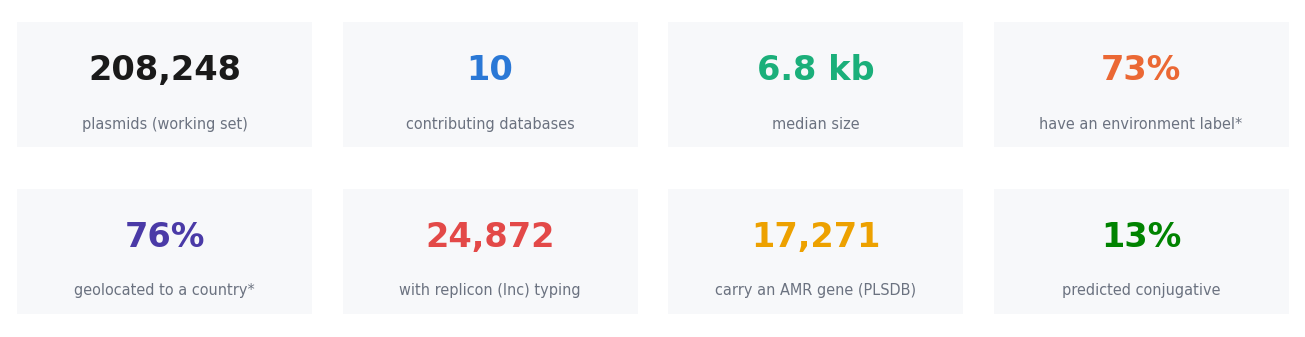

* percentages are of the 143,590 analysis plasmids (simulated-community artifact excluded)


In [3]:
def stat_tiles(items, ncol=4, figsize=(12, 3.2)):
    nrow = int(np.ceil(len(items) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, (big, label, color) in zip(axes, items):
        ax.axis("off")
        ax.add_patch(plt.Rectangle((0.02, 0.08), 0.96, 0.84, transform=ax.transAxes,
                                   facecolor="#f7f8fa", edgecolor="none"))
        ax.text(0.5, 0.60, big, transform=ax.transAxes, ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)
        ax.text(0.5, 0.24, label, transform=ax.transAxes, ha="center", va="center",
                fontsize=9.5, color=MUTED)
    for ax in axes[len(items):]:
        ax.axis("off")
    fig.tight_layout()
    return fig

tiles = [
    (f"{len(M):,}", "plasmids (working set)", INK),
    (f"{M.sources.str.split(';').explode().nunique()}", "contributing databases", PAL[0]),
    (f"{M.size_bp.median()/1000:.1f} kb", "median size", PAL[1]),
    (f"{(R.hab_top != 'Unknown').mean()*100:.0f}%", "have an environment label*", PAL[7]),
    (f"{(R.geo_country != '').mean()*100:.0f}%", "geolocated to a country*", PAL[4]),
    (f"{(M.plsdb_inc_types != '').sum():,}", "with replicon (Inc) typing", PAL[5]),
    (f"{(M.plsdb_amr_genes != '').sum():,}", "carry an AMR gene (PLSDB)", PAL[2]),
    (f"{(M.predicted_mobility == 'conjugative').mean()*100:.0f}%", "predicted conjugative", PAL[3]),
]
fig = stat_tiles(tiles)
save(fig, "00_glance")
plt.show()
print("* percentages are of the 143,590 analysis plasmids (simulated-community artifact excluded)")

## 1 · Data source & provenance

Which databases each plasmid comes from (`sources`, multi-valued) and how many independent databases
back it (`n_source_dbs`). PlasmidScope deduplicated at 100% identity/coverage, so a plasmid seen in
several source DBs is one physical sequence with corroborating provenance — not a duplicate.

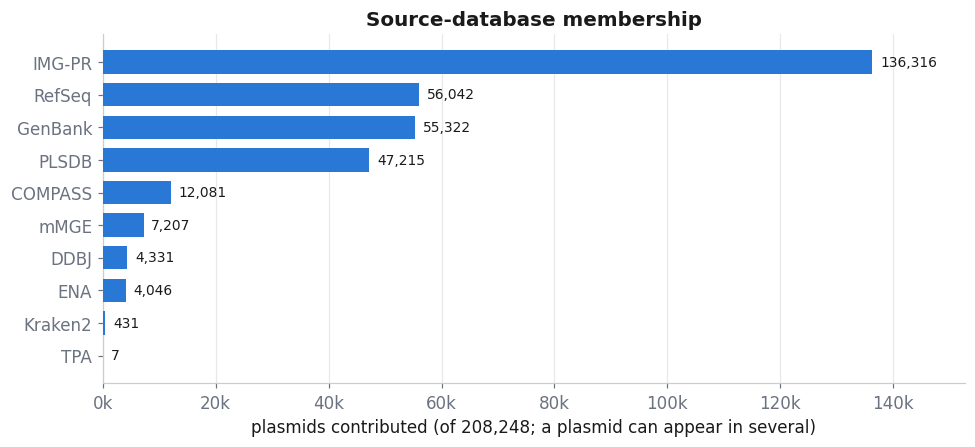

In [4]:
# --- 1a: per-database membership -------------------------------------------------------
memb = Counter()
for s in M.sources:
    for db in s.split(";"):
        if db:
            memb[db] += 1
memb = pd.Series(memb).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(memb.index, memb.values, color=PAL[0], height=0.72, zorder=3)
hbar_labels(ax, memb.values)
ax.set_title("Source-database membership")
ax.set_xlabel("plasmids contributed (of 208,248; a plasmid can appear in several)")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "01a_source_membership"); plt.show()

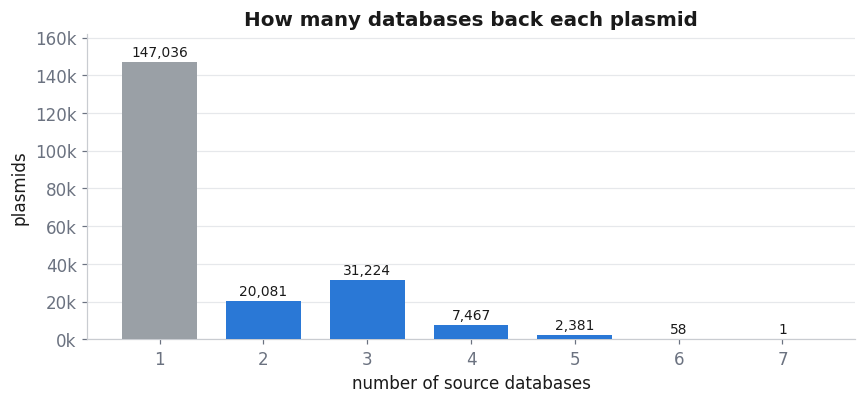

single-source: 70.6%  |  multi-source (>=2 DBs corroborate): 29.4%


In [5]:
# --- 1b: provenance multiplicity -------------------------------------------------------
nd = M.n_source_dbs.value_counts().sort_index()
single = nd.get(1, 0) / len(M) * 100

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(nd.index.astype(int).astype(str), nd.values,
              color=[GREY if k == 1 else PAL[0] for k in nd.index], width=0.72, zorder=3)
for b, v in zip(bars, nd.values):
    ax.text(b.get_x() + b.get_width()/2, v + max(nd.values)*0.01, f"{v:,}",
            ha="center", va="bottom", fontsize=9, color=INK)
ax.set_title("How many databases back each plasmid")
ax.set_xlabel("number of source databases"); ax.set_ylabel("plasmids")
ax.set_ylim(0, max(nd.values) * 1.10)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "01b_provenance_multiplicity"); plt.show()
print(f"single-source: {single:.1f}%  |  multi-source (>=2 DBs corroborate): {100-single:.1f}%")

## 2 · Plasmid physical properties

Size, GC content, topology and predicted mobility. These are intrinsic sequence properties, so all
208,248 plasmids are included here (the artifact caveat only affects habitat/geography). Size spans
five orders of magnitude, so it is shown on a log axis.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


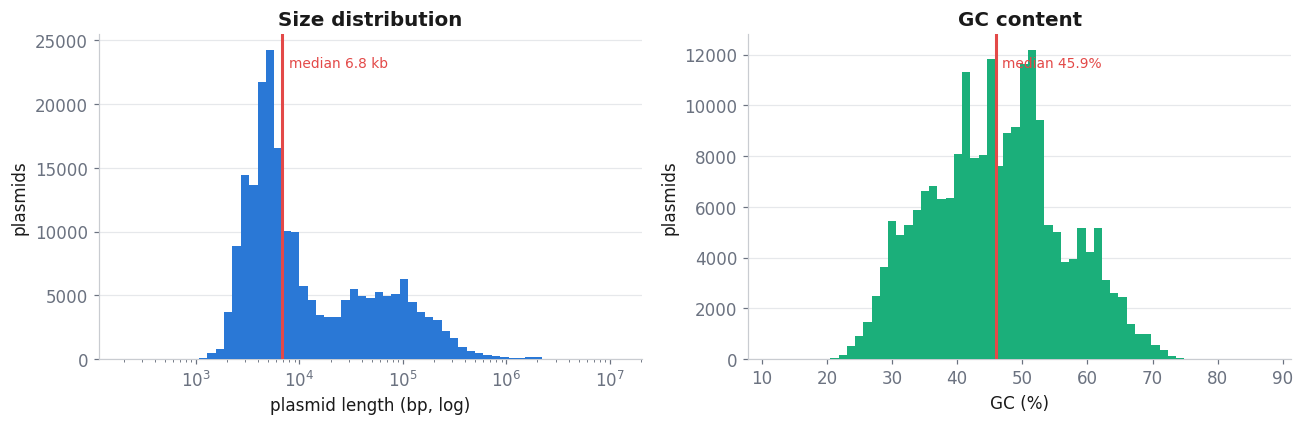

In [6]:
# --- 2a: size + 2b: GC (side by side) --------------------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))

lo, hi = M.size_bp.min(), M.size_bp.max()
bins = np.logspace(np.log10(lo), np.log10(hi), 60)
a1.hist(M.size_bp, bins=bins, color=PAL[0], zorder=3)
a1.set_xscale("log")
a1.axvline(M.size_bp.median(), color=PAL[5], lw=2, zorder=4)
a1.text(M.size_bp.median()*1.15, a1.get_ylim()[1]*0.9,
        f"median {M.size_bp.median()/1000:.1f} kb", color=PAL[5], fontsize=9)
a1.set_title("Size distribution"); a1.set_xlabel("plasmid length (bp, log)"); a1.set_ylabel("plasmids")
a1.grid(axis="x", visible=False)

a2.hist(M.gc_percent, bins=60, color=PAL[1], zorder=3)
a2.axvline(M.gc_percent.median(), color=PAL[5], lw=2, zorder=4)
a2.text(M.gc_percent.median()+1, a2.get_ylim()[1]*0.9,
        f"median {M.gc_percent.median():.1f}%", color=PAL[5], fontsize=9)
a2.set_title("GC content"); a2.set_xlabel("GC (%)"); a2.set_ylabel("plasmids")
a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "02ab_size_gc"); plt.show()

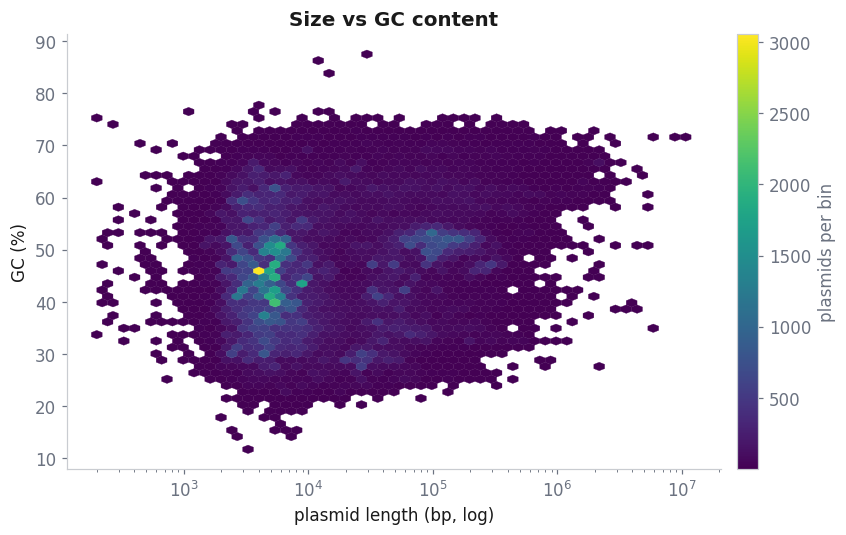

In [7]:
# --- 2c: size vs GC density (hexbin, sequential) ---------------------------------------
cmap = "mako_r" if "mako_r" in plt.colormaps() else "viridis"
fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(M.size_bp, M.gc_percent, xscale="log", gridsize=55, cmap=cmap,
               mincnt=1, linewidths=0.2)
cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label("plasmids per bin", color=MUTED)
ax.set_title("Size vs GC content"); ax.set_xlabel("plasmid length (bp, log)"); ax.set_ylabel("GC (%)")
ax.grid(False)
fig.tight_layout(); save(fig, "02c_size_vs_gc"); plt.show()

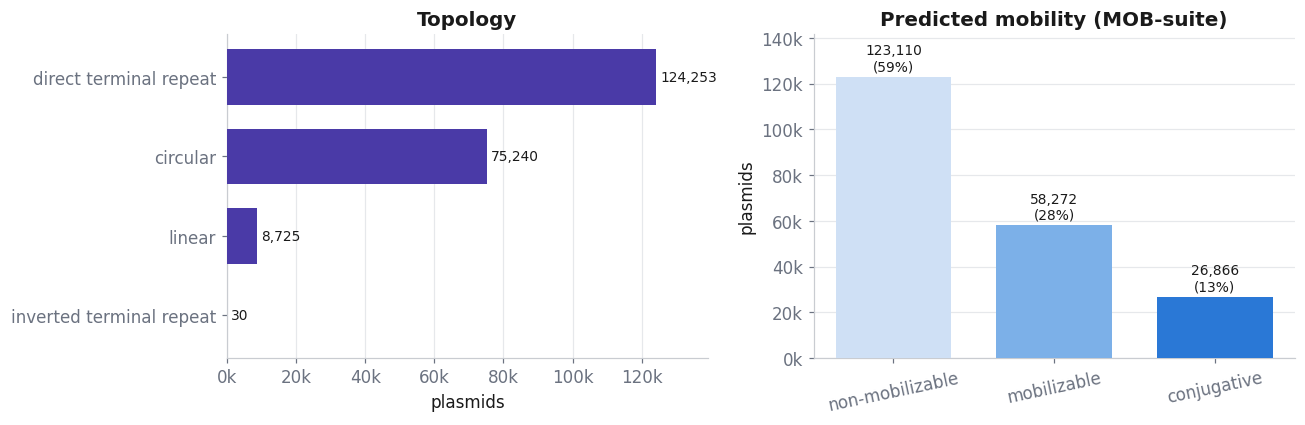

In [8]:
# --- 2d: topology + 2e: predicted mobility ---------------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))

topo = M.topology.replace("", "unspecified").value_counts()
a1.barh(topo.index[::-1], topo.values[::-1], color=PAL[4], height=0.7, zorder=3)
hbar_labels(a1, topo.values[::-1])
a1.set_title("Topology"); a1.set_xlabel("plasmids")
a1.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
a1.grid(axis="y", visible=False)

# mobility is an ordered scale -> sequential blue ramp (light=inert -> dark=conjugative)
MOB_ORDER = ["non-mobilizable", "mobilizable", "conjugative"]
MOB_COL = {"non-mobilizable": "#cfe0f5", "mobilizable": "#7cb0e8", "conjugative": "#2a78d6"}
mob = M.predicted_mobility.value_counts().reindex(MOB_ORDER)
bars = a2.bar(range(3), mob.values, color=[MOB_COL[m] for m in MOB_ORDER], width=0.72, zorder=3)
a2.set_xticks(range(3)); a2.set_xticklabels(MOB_ORDER, rotation=12)
for b, v in zip(bars, mob.values):
    a2.text(b.get_x()+b.get_width()/2, v+max(mob.values)*0.01,
            f"{v:,}\n({v/len(M)*100:.0f}%)", ha="center", va="bottom", fontsize=9, color=INK)
a2.set_title("Predicted mobility (MOB-suite)"); a2.set_ylabel("plasmids")
a2.set_ylim(0, max(mob.values)*1.15)
a2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "02de_topology_mobility"); plt.show()

## 3 · Environment — where the plasmids were sampled

The **locked** environment taxonomy (`scripts/reconcile_environment.py`,
`reports/environment_taxonomy_LOCKED.md`). Two axes, deliberately kept separate:

- **`sources`** — the *database provenance* (§1). Not an environment.
- **`hab_top` / `hab_sub`** — the *reconciled habitat*: is the plasmid from wastewater, human faeces,
  soil, blood…? A per-plasmid `is_clinical` flag is nested under Host-associated;Human.

The confusing metagenomic-vs-isolate "lifestyle" tag was **dropped** — a source-DB label does not
reflect the true sample origin (clinical datasets contain metagenomic samples). `hab_channel` records
which upstream source supplied the habitat label (GOLD / BioSample / SRA).

All panels below use the **analysis set** (`R`, both simulated-community and lab artifacts excluded).

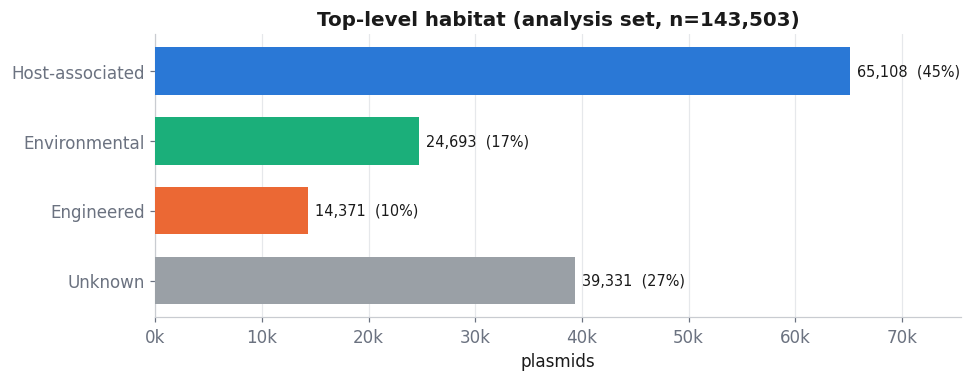

(excluded: 64,658 simulated-community + 87 lab-artifact plasmids — not real habitats)


In [9]:
# --- 3a: top-level habitat composition -------------------------------------------------
ORDER = ["Host-associated", "Environmental", "Engineered", "Unknown"]
top = R.hab_top.value_counts().reindex(ORDER)

fig, ax = plt.subplots(figsize=(9, 3.6))
y = list(range(len(ORDER)))[::-1]
ax.barh(y, top.values, color=[HAB_COLORS[h] for h in ORDER], height=0.68, zorder=3)
ax.set_yticks(y); ax.set_yticklabels(ORDER)
for yi, v in zip(y, top.values):
    ax.text(v + max(top.values)*0.01, yi, f"{v:,}  ({v/len(R)*100:.0f}%)",
            va="center", ha="left", fontsize=9.5, color=INK)
ax.set_xlim(0, max(top.values)*1.16)
ax.set_title("Top-level habitat (analysis set, n=143,503)")
ax.set_xlabel("plasmids")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "03a_habitat_top"); plt.show()
print("(excluded: 64,658 simulated-community + 87 lab-artifact plasmids — not real habitats)")

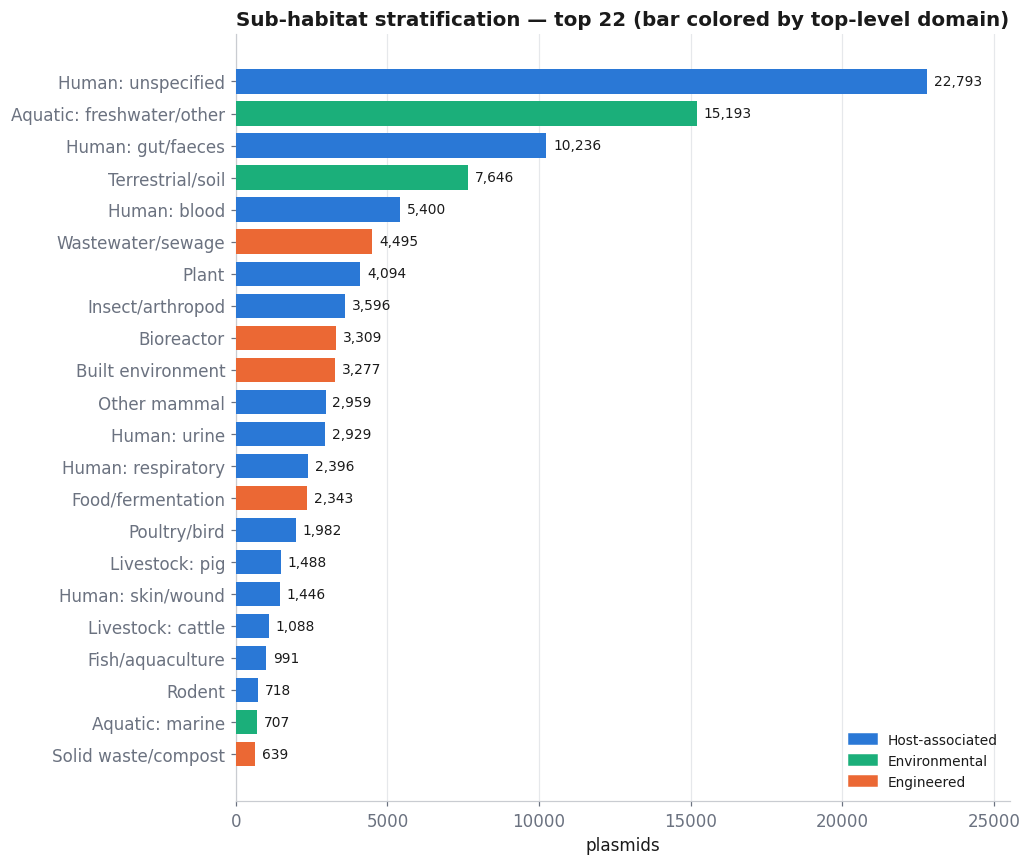

In [10]:
# --- 3b: sub-habitat stratification (the granular answer) ------------------------------
parent = (R[(R.hab_sub != "")].groupby("hab_sub")["hab_top"]
          .agg(lambda s: s.mode().iat[0]))
DROP = {"Unlabelled", "Unresolved", "Geography only (no habitat)"}
sub = R.loc[~R.hab_sub.isin(DROP) & (R.hab_sub != ""), "hab_sub"].value_counts().head(22).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 8))
colors = [HAB_COLORS.get(parent.get(s, "Unknown"), GREY) for s in sub.index]
ax.barh(sub.index, sub.values, color=colors, height=0.76, zorder=3)
hbar_labels(ax, sub.values)
ax.set_title("Sub-habitat stratification — top 22 (bar colored by top-level domain)")
ax.set_xlabel("plasmids")
handles = [plt.Rectangle((0, 0), 1, 1, color=HAB_COLORS[h]) for h in ORDER[:3]]
ax.legend(handles, ORDER[:3], loc="lower right", fontsize=9)
ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "03b_habitat_sub"); plt.show()

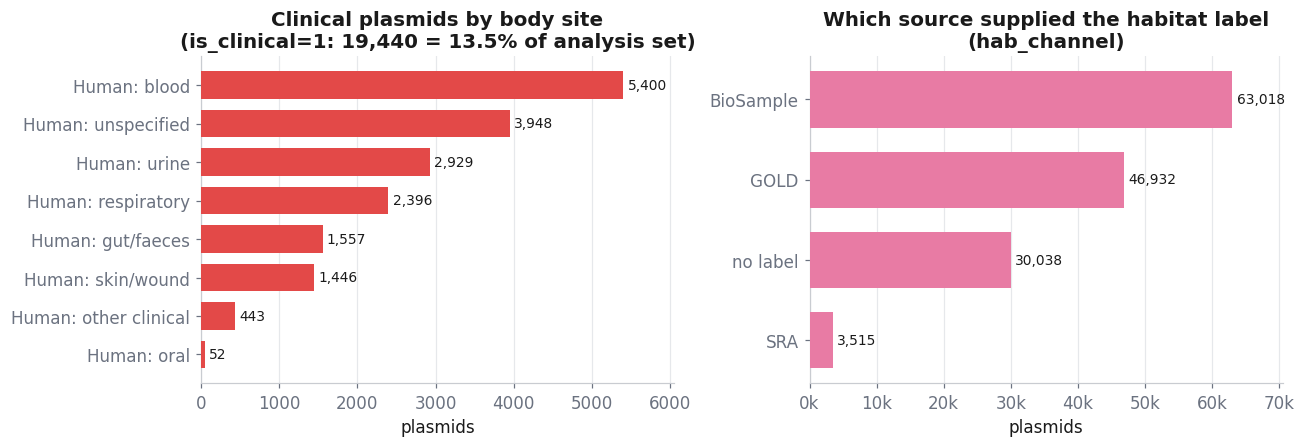

In [11]:
# --- 3c: clinical body sites + 3d: label channel ---------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))

clin = R.loc[R.is_clinical == 1, "hab_sub"].value_counts()
clin = clin[clin.index.str.startswith("Human")].head(8).sort_values()
a1.barh(clin.index, clin.values, color=PAL[5], height=0.72, zorder=3)
hbar_labels(a1, clin.values)
a1.set_title(f"Clinical plasmids by body site\n(is_clinical=1: {int((R.is_clinical==1).sum()):,} = "
             f"{(R.is_clinical==1).mean()*100:.1f}% of analysis set)")
a1.set_xlabel("plasmids"); a1.grid(axis="y", visible=False)

ch = R.hab_channel.replace("", "no label").value_counts()
a2.barh(ch.index[::-1], ch.values[::-1], color=PAL[6], height=0.7, zorder=3)
hbar_labels(a2, ch.values[::-1])
a2.set_title("Which source supplied the habitat label\n(hab_channel)")
a2.set_xlabel("plasmids")
a2.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
a2.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "03cd_clinical_channel"); plt.show()

## 4 · Replicon typing & antimicrobial resistance

Replicon (Inc/rep) typing, multireplicon status, and AMR gene content. **These come from the PLSDB
curated layer, which covers 45,743 of the 208,248 plasmids (22%)** — the remaining plasmids are not yet
replicon-typed (a genome-wide MOB-suite/PlasmidFinder run is the next pipeline gate). Every panel below
is *conditioned on the PLSDB-typed subset* and labelled as such; do not read these as whole-set rates.

PLSDB replicon-typed subset: 24,872 plasmids


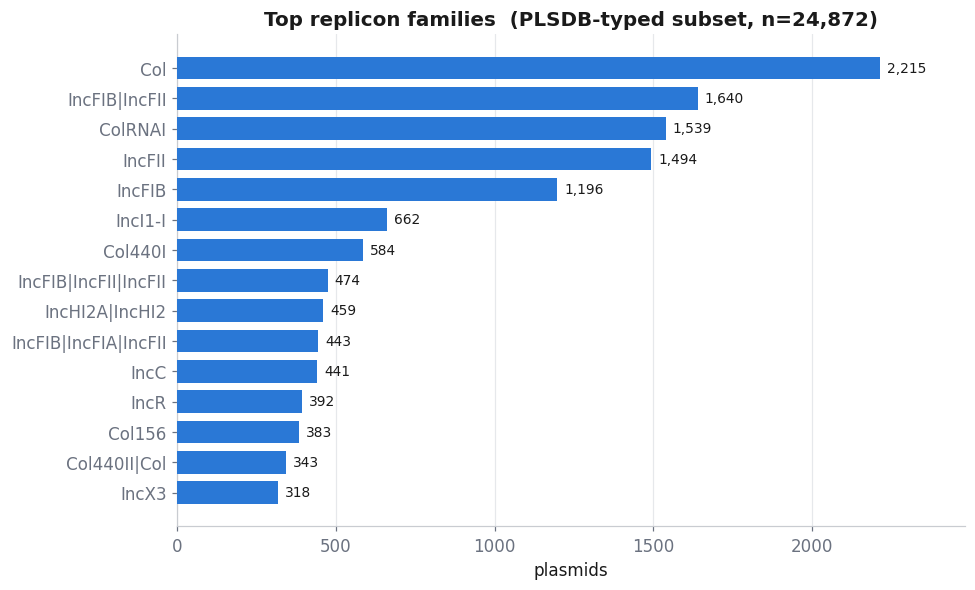

In [12]:
PT = M[M.plsdb_inc_types != ""].copy()      # PLSDB replicon-typed subset
print(f"PLSDB replicon-typed subset: {len(PT):,} plasmids")

# --- 4a: top Inc families (collapse allelic variants IncFIB(K)->IncFIB) ----------------
famc = Counter()
for s in PT.plsdb_inc_types:
    for x in re.split(r"[;,]", s):
        x = re.sub(r"\(.*?\)", "", x).strip()
        if x:
            famc[x] += 1
fam = pd.Series(famc).sort_values().tail(15)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(fam.index, fam.values, color=PAL[0], height=0.74, zorder=3)
hbar_labels(ax, fam.values)
ax.set_title(f"Top replicon families  (PLSDB-typed subset, n={len(PT):,})")
ax.set_xlabel("plasmids"); ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "04a_inc_families"); plt.show()

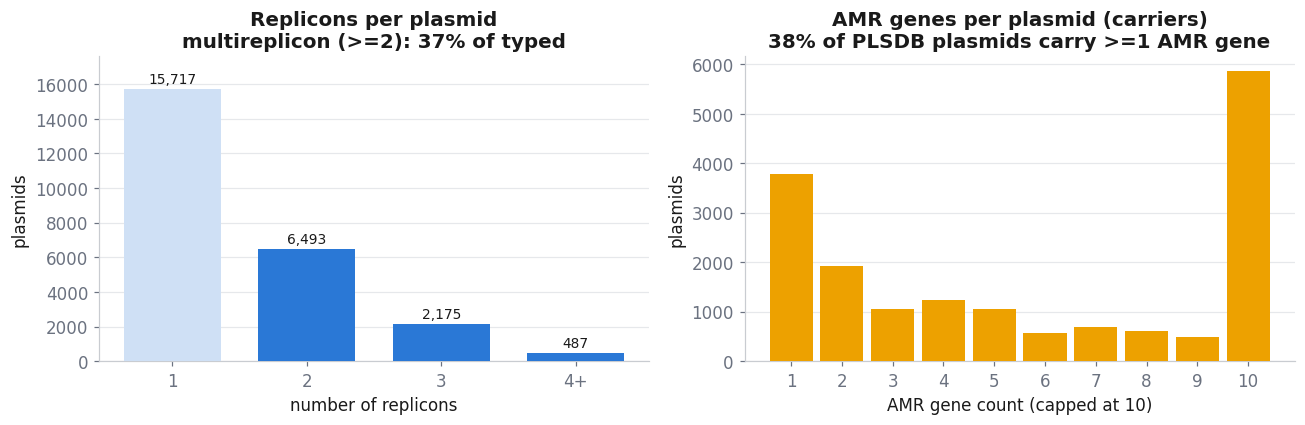

In [13]:
# --- 4b: multireplicon + 4c: AMR gene burden -------------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))

ninc = PT.plsdb_n_inc.fillna(0).astype(int).clip(upper=4)
lab = {0: "0", 1: "1", 2: "2", 3: "3", 4: "4+"}
vc = ninc.value_counts().sort_index()
cols = ["#cfe0f5" if k <= 1 else PAL[0] for k in vc.index]
bars = a1.bar([lab[k] for k in vc.index], vc.values, color=cols, width=0.72, zorder=3)
multi = (ninc >= 2).mean() * 100
for b, v in zip(bars, vc.values):
    a1.text(b.get_x()+b.get_width()/2, v+max(vc.values)*0.01, f"{v:,}",
            ha="center", va="bottom", fontsize=9, color=INK)
a1.set_title(f"Replicons per plasmid\nmultireplicon (>=2): {multi:.0f}% of typed")
a1.set_xlabel("number of replicons"); a1.set_ylabel("plasmids"); a1.set_ylim(0, max(vc.values)*1.12)
a1.grid(axis="x", visible=False)

# AMR gene burden among PLSDB carriers
amr_sub = M[M.plsdb_acc != ""]
carry = (amr_sub.plsdb_amr_genes != "").mean() * 100
na = amr_sub.loc[amr_sub.plsdb_amr_genes != "", "plsdb_n_amr"].fillna(0).astype(int).clip(upper=10)
a2.hist(na, bins=range(1, 12), color=PAL[2], align="left", rwidth=0.85, zorder=3)
a2.set_title(f"AMR genes per plasmid (carriers)\n{carry:.0f}% of PLSDB plasmids carry >=1 AMR gene")
a2.set_xlabel("AMR gene count (capped at 10)"); a2.set_ylabel("plasmids")
a2.set_xticks(range(1, 11)); a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "04bc_multireplicon_amr"); plt.show()

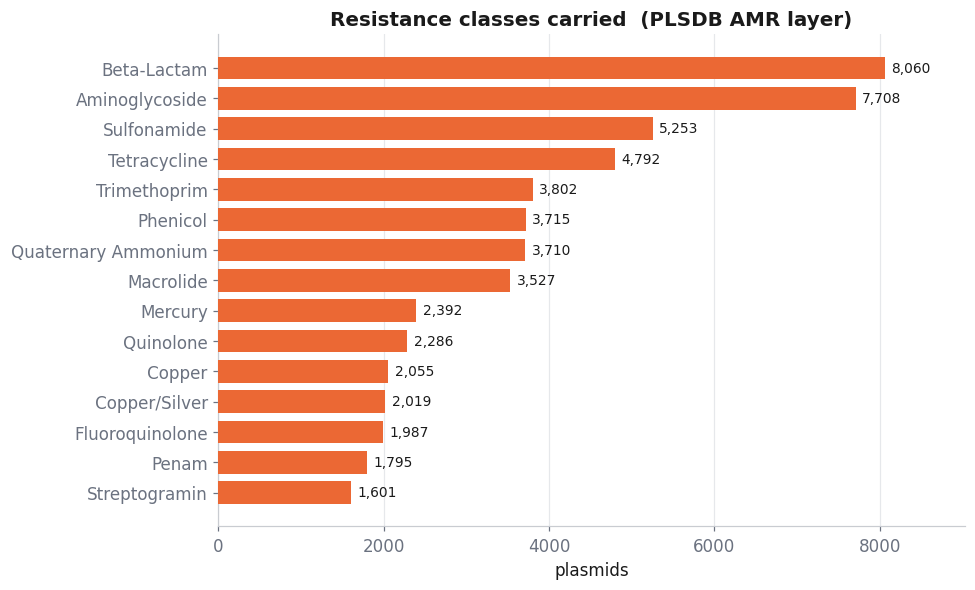

In [14]:
# --- 4d: top drug classes (normalize the two vocabularies) -----------------------------
def norm_drug(x):
    x = x.strip().lower()
    x = re.sub(r"\s*antibiotic$", "", x)
    return x

dc = Counter()
for s in M.plsdb_drug_classes:
    seen = set()
    for x in re.split(r"[;,|]", s):
        x = norm_drug(x)
        if x and x not in seen:
            seen.add(x)
            dc[x] += 1
drug = pd.Series(dc).sort_values().tail(15)
drug.index = [d.title() for d in drug.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(drug.index, drug.values, color=PAL[7], height=0.74, zorder=3)
hbar_labels(ax, drug.values)
ax.set_title("Resistance classes carried  (PLSDB AMR layer)")
ax.set_xlabel("plasmids"); ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "04d_drug_classes"); plt.show()

## 5 · Geography

Sampling location, maximised across BioSample `lat_lon`, PLSDB coordinates, scraped IMG/M sample
coordinates, and empirical country centroids for place-name-only records (`scripts/geo_utils.py`).
The simulated-community artifact is excluded (its coordinates are the JGI compute site). Coverage on the
analysis set is high for isolate-backed plasmids and limited for metagenomic ones.

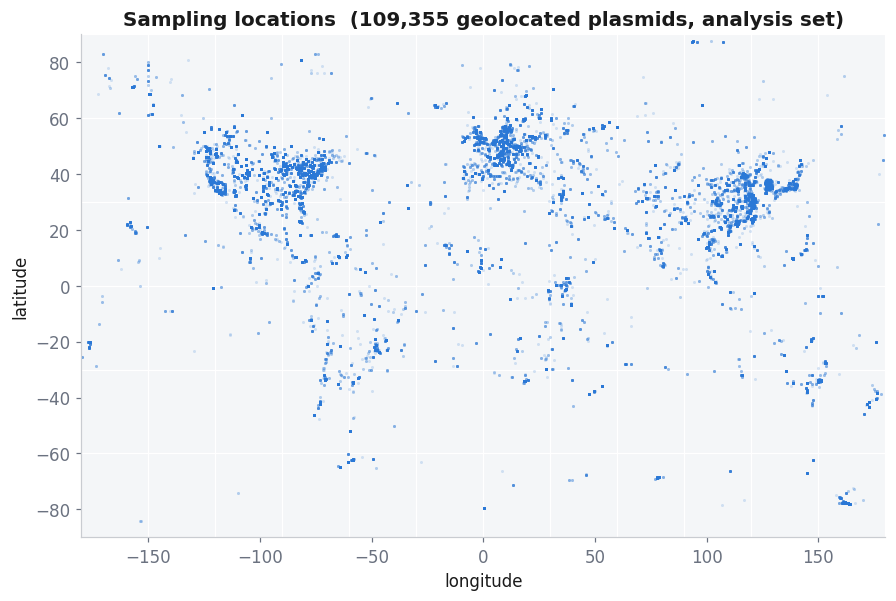

In [15]:
# --- 5a: world map (equirectangular; no cartopy) ---------------------------------------
G = R[(R.geo_lat.notna()) & (R.geo_lng.notna())]
fig, ax = plt.subplots(figsize=(12, 5.6))
ax.set_facecolor("#f4f6f8")
for x in range(-180, 181, 30):
    ax.axvline(x, color="white", lw=0.8, zorder=1)
for yv in range(-90, 91, 30):
    ax.axhline(yv, color="white", lw=0.8, zorder=1)
ax.scatter(G.geo_lng, G.geo_lat, s=4, c=PAL[0], alpha=0.18, linewidths=0, zorder=2)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90); ax.set_aspect(1.25)
ax.set_title(f"Sampling locations  ({len(G):,} geolocated plasmids, analysis set)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.grid(False)
fig.tight_layout(); save(fig, "05a_world_map"); plt.show()

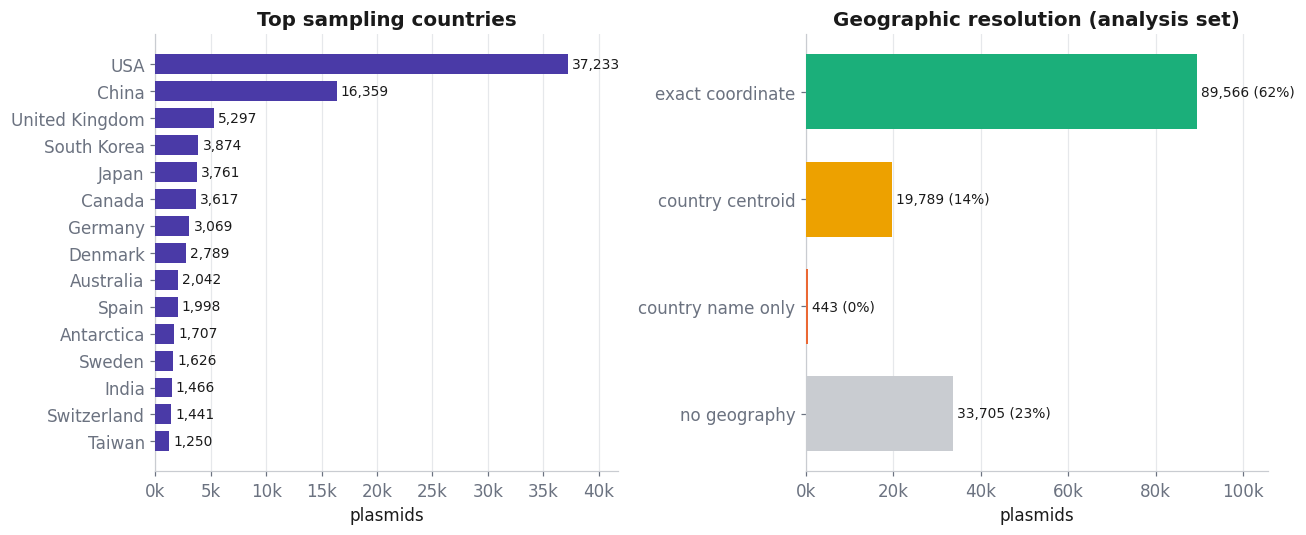

In [16]:
# --- 5b: top countries + 5c: coverage by precision -------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))

ctry = R.loc[R.geo_country != "", "geo_country"].value_counts().head(15).sort_values()
a1.barh(ctry.index, ctry.values, color=PAL[4], height=0.74, zorder=3)
hbar_labels(a1, ctry.values)
a1.set_title("Top sampling countries"); a1.set_xlabel("plasmids")
a1.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
a1.grid(axis="y", visible=False)

PREC = {"point": "exact coordinate", "country_centroid": "country centroid",
        "country_only": "country name only", "": "no geography"}
pc = R.geo_precision.map(lambda p: PREC.get(p, p)).value_counts()
pc = pc.reindex([PREC[k] for k in ["point", "country_centroid", "country_only", ""]]).dropna()
pcol = {"exact coordinate": PAL[1], "country centroid": PAL[2],
        "country name only": PAL[7], "no geography": LGREY}
order = list(pc.index[::-1])
a2.barh(order, pc.values[::-1], color=[pcol[i] for i in order], height=0.7, zorder=3)
for i, v in enumerate(pc.values[::-1]):
    a2.text(v + max(pc.values)*0.01, i, f"{v:,} ({v/len(R)*100:.0f}%)",
            va="center", ha="left", fontsize=9, color=INK)
a2.set_xlim(0, max(pc.values)*1.18)
a2.set_title("Geographic resolution (analysis set)"); a2.set_xlabel("plasmids")
a2.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
a2.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "05bc_countries_precision"); plt.show()

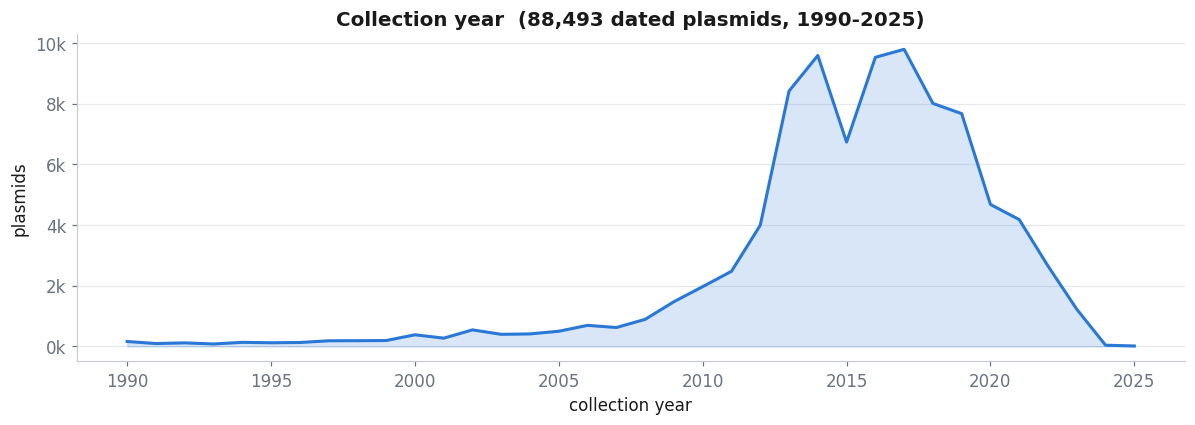

In [17]:
# --- 5d: collection-year timeline ------------------------------------------------------
yr = pd.to_numeric(R.collection_date.str.extract(r"(19\d\d|20\d\d)")[0], errors="coerce")
yr = yr[(yr >= 1990) & (yr <= 2025)]
counts = yr.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(counts.index, counts.values, color=PAL[0], alpha=0.18, zorder=2)
ax.plot(counts.index, counts.values, color=PAL[0], lw=2, zorder=3)
ax.set_title(f"Collection year  ({int(yr.notna().sum()):,} dated plasmids, 1990-2025)")
ax.set_xlabel("collection year"); ax.set_ylabel("plasmids")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "05d_collection_year"); plt.show()

## 6 · Cross-cutting views

Integrative panels that combine axes: does mobility vary by habitat? Is AMR concentrated in particular
environments? How does size differ across domains? All on the analysis set; the AMR panel is conditioned
on the PLSDB subset within each habitat and labelled accordingly.

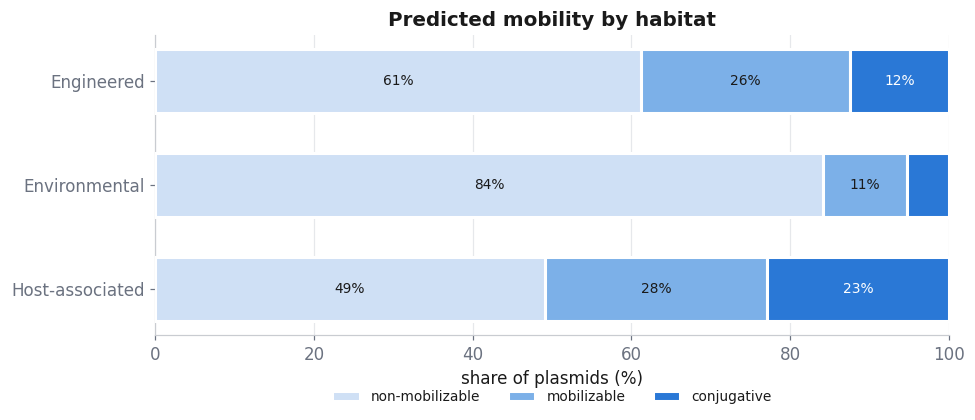

In [18]:
# --- 6a: mobility composition by habitat (stacked proportions) -------------------------
DOM = ["Host-associated", "Environmental", "Engineered"]
MOB_ORDER = ["non-mobilizable", "mobilizable", "conjugative"]
MOB_COL = {"non-mobilizable": "#cfe0f5", "mobilizable": "#7cb0e8", "conjugative": "#2a78d6"}

ct = (R[R.hab_top.isin(DOM)]
      .groupby("hab_top")["predicted_mobility"].value_counts(normalize=True)
      .unstack().reindex(index=DOM, columns=MOB_ORDER) * 100)

fig, ax = plt.subplots(figsize=(9, 4))
left = np.zeros(len(DOM))
for m in MOB_ORDER:
    ax.barh(DOM, ct[m].values, left=left, color=MOB_COL[m], height=0.62,
            label=m, edgecolor="white", linewidth=2, zorder=3)
    for i, (v, l) in enumerate(zip(ct[m].values, left)):
        if v > 6:
            ax.text(l + v/2, i, f"{v:.0f}%", va="center", ha="center", fontsize=9,
                    color="white" if m == "conjugative" else INK)
    left += ct[m].values
ax.set_xlim(0, 100); ax.set_xlabel("share of plasmids (%)")
ax.set_title("Predicted mobility by habitat")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, fontsize=9)
ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "06a_mobility_by_habitat"); plt.show()

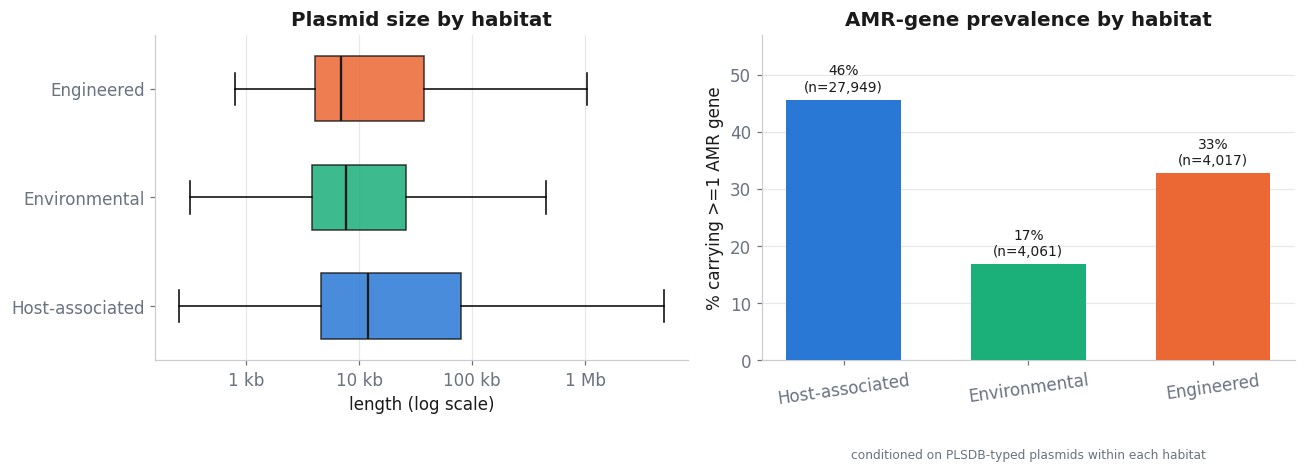

In [19]:
# --- 6b: size distribution by habitat (box) + 6c: AMR prevalence by habitat ------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))

data = [np.log10(R.loc[R.hab_top == d, "size_bp"].dropna()) for d in DOM]
bp = a1.boxplot(data, vert=False, patch_artist=True, widths=0.6, showfliers=False)
for patch, d in zip(bp["boxes"], DOM):
    patch.set_facecolor(HAB_COLORS[d]); patch.set_alpha(0.85); patch.set_edgecolor(INK)
for med in bp["medians"]:
    med.set_color(INK); med.set_linewidth(1.5)
a1.set_yticks(range(1, len(DOM)+1)); a1.set_yticklabels(DOM)
a1.set_xticks([3, 4, 5, 6]); a1.set_xticklabels(["1 kb", "10 kb", "100 kb", "1 Mb"])
a1.set_title("Plasmid size by habitat"); a1.set_xlabel("length (log scale)")
a1.grid(axis="y", visible=False)

amr = R[R.plsdb_acc != ""].copy()
amr["has_amr"] = (amr.plsdb_amr_genes != "").astype(int)
prev = amr[amr.hab_top.isin(DOM)].groupby("hab_top").agg(
    pct=("has_amr", "mean"), n=("has_amr", "size")).reindex(DOM)
prev["pct"] *= 100
bars = a2.bar(range(len(DOM)), prev.pct.values, color=[HAB_COLORS[d] for d in DOM],
              width=0.62, zorder=3)
for b, p, n in zip(bars, prev.pct.values, prev.n.values):
    a2.text(b.get_x()+b.get_width()/2, p+1, f"{p:.0f}%\n(n={int(n):,})",
            ha="center", va="bottom", fontsize=9, color=INK)
a2.set_ylim(0, max(prev.pct.values)*1.25)
a2.set_xticks(range(len(DOM))); a2.set_xticklabels(DOM, rotation=8)
a2.set_title("AMR-gene prevalence by habitat"); a2.set_ylabel("% carrying >=1 AMR gene")
a2.text(0.5, -0.30, "conditioned on PLSDB-typed plasmids within each habitat",
        transform=a2.transAxes, ha="center", fontsize=8, color=MUTED)
a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "06bc_size_amr_by_habitat"); plt.show()

## 7 · Summary & data dictionary

**Headline findings**

- **Provenance.** 208,248 plasmids, dominated by IMG/PR (136k) with strong RefSeq/GenBank/PLSDB
  corroboration; ~29% are backed by ≥2 independent databases.
- **Physical.** Median ~6.8 kb but a heavy tail to >1 Mb; GC centred ~46%. Most plasmids are predicted
  non-mobilizable, ~13% conjugative.
- **Environment (analysis set, 143,503).** Host-associated is the largest domain, then Environmental
  then Engineered; ~27% remain Unknown. Sub-habitat stratification resolves the granular question —
  human gut/faeces, freshwater, soil, blood and wastewater/sewage are the leading specific habitats.
  9.3% carry the clinical flag.
- **Typing & AMR (PLSDB subset).** IncF/Col/IncR families dominate; multireplicon plasmids are a
  sizeable minority; β-lactam and aminoglycoside resistance lead the AMR classes. **Coverage is the
  key limitation — only 22% are replicon-typed; a genome-wide typing run is the next gate.**
- **Geography.** Strongly skewed to the USA and China; resolution is exact-coordinate for most
  geolocated plasmids, with the balance placed at country centroids.

**Data dictionary (master table columns)**

| column | meaning |
|---|---|
| `plasmid_id`, `sources`, `n_source_dbs` | rep id; contributing databases; provenance multiplicity |
| `topology`, `size_bp`, `gc_percent` | physical properties |
| `predicted_mobility`, `mob_families` | MOB-suite mobility class & relaxase family |
| `hab_top`, `hab_sub`, `hab_channel`, `is_clinical` | locked environment taxonomy (§3) |
| `plsdb_*` | PLSDB curated layer: Inc/rep typing, MOB, AMR genes/classes, ecosystem, disease, species |
| `geo_country`, `geo_admin1`, `geo_lat`, `geo_lng`, `geo_precision`, `geo_source`, `collection_date` | maximised geography |

*Generated by `scripts/build_investigation_notebook.py`; all data from
`data/plasmidscope_primary/plasmid_metadata_master.tsv`. Figures written to
`reports/figures/investigation/`.*